In [1]:

import warnings
warnings.filterwarnings("ignore")

# Standard Library
import argparse
import datetime as dt
from datetime import datetime
from pathlib import Path
from io import BytesIO
from typing import Any, Dict, NamedTuple, Tuple, Union, Optional
from netrc import netrc
from subprocess import Popen
from platform import system
from getpass import getpass
import shutil
import os

import json
import time
import warnings
import zipfile
import logging

# Third-Party Libraries
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import xarray as xr
import rasterio
from rasterio import merge
from rasterio.transform import from_origin
from rasterio.crs import CRS
from rasterio.transform import Affine
from ipyleaflet import Map, Marker, DrawControl, GeoJSON, FeatureGroup, LayersControl
from ipywidgets import Output, Checkbox, VBox, ToggleButton
from ipyleaflet import CircleMarker
import rioxarray
import pyproj
from shapely import wkt
from shapely.geometry import box, Point, shape
import shapely
import cartopy.crs as ccrs
from concurrent.futures import ThreadPoolExecutor, as_completed
import requests
import asf_search as asf
import xyzservices
from tqdm import tqdm
import h5py

# Project-Specific Imports
import opera_utils
from opera_utils.disp._search import search
from opera_utils.geometry import stitch_geometry_layers
from opera_utils.download import L2Product
from disp_xr import download, static_layers, product, stack as disp_stack, quality_metrics, io
from disp_xr.log.logging import setup_logging
from disp_xr.utils import latlon_to_utm, get_extent, find_reference_point
from mintpy.utils import utils as ut
warnings.simplefilter("ignore") 

# Functions

In [ ]:
def process_file(url, bbox, outdir, username, password):
    filename = url.split("/")[-1]
    base, ext = os.path.splitext(filename)
    outname = f"{outdir}/{base}.nc"

    if os.path.exists(outname):
        print(f"Skipped (exists): {filename}")
        return
    
    session = requests.Session()
    session.auth = (username, password)
    response = session.get(url)
    response.raise_for_status()
    file_bytes = BytesIO(response.content)

    if bbox is not None:
        with h5py.File(file_bytes, "r") as h5f:
            # Open and slice root data
            ds = xr.open_dataset(h5f, engine="h5netcdf")
            subset = ds.isel(y=slice(bbox[2], bbox[3]), x=slice(bbox[0], bbox[1]))
            subset.to_netcdf(outname)
            ds.close() 

            # Also subset and add /corrections data
            ds_corr = xr.open_dataset(h5f, engine="h5netcdf", group="corrections")
            corr_subset = ds_corr.isel(y=slice(bbox[2], bbox[3]), x=slice(bbox[0], bbox[1]))
            corr_subset.to_netcdf(outname, mode="a", group="corrections")
            ds_corr.close() 

            # Add metadata-only groups with xarray
            for group in ["identification", "metadata"]:
                try:
                    meta = xr.open_dataset(h5f, engine="h5netcdf", group=group)
                    meta.to_netcdf(outname, mode="a", group=group)
                    meta.close()
                except Exception as e:
                    print(f"Warning: Could not write {group}: {e}")

            # Append broken subgroups with h5py
            copy_group_h5py(h5f, outname, "metadata/reference_orbit")
            copy_group_h5py(h5f, outname, "metadata/secondary_orbit")
    else:
        with h5py.File(file_bytes, "r") as h5f:
            ds = xr.open_dataset(h5f, engine="h5netcdf")
            ds.to_netcdf(outname)
            ds.close()
            ds_corr = xr.open_dataset(h5f, engine="h5netcdf", group="corrections")
            ds_corr.to_netcdf(outname, mode="a", group="corrections")
            ds_corr.close()
            
            # Add metadata-only groups with xarray
            for group in ["identification", "metadata"]:
                try:
                    meta = xr.open_dataset(h5f, engine="h5netcdf", group=group)
                    meta.to_netcdf(outname, mode="a", group=group)
                    meta.close()
                except Exception as e:
                    print(f"Warning: Could not write {group}: {e}")

            # Append broken subgroups with h5py
            copy_group_h5py(h5f, outname, "metadata/reference_orbit")
            copy_group_h5py(h5f, outname, "metadata/secondary_orbit")

    print(f"Done: {filename}")

def extract_pixel_bbox_from_lalo(coord, lonlat_bbox):
    min_lon,  max_lon, min_lat, max_lat = lonlat_bbox.values()
    y0, x0 = coord.lalo2yx(min_lat, min_lon)
    y1, x1 = coord.lalo2yx(max_lat, max_lon)
    return slice(int(min(y0, y1)), int(max(y0, y1))), slice(int(min(x0, x1)), int(max(x0, x1)))

def copy_group_h5py(source_h5, target_path, group_name):
    try:
        with h5py.File(target_path, "a") as target_h5:
            src_group = source_h5[group_name]
            tgt_group = target_h5.require_group(group_name)

            for name, dataset in src_group.items():
                if name in tgt_group:
                    del tgt_group[name]
                tgt_ds = tgt_group.create_dataset(name, data=dataset[()])
                for key, val in dataset.attrs.items():
                    tgt_ds.attrs[key] = val

            for key, val in src_group.attrs.items():
                tgt_group.attrs[key] = val

    except Exception as e:
        print(f" Failed to copy {group_name} with h5py: {e}")
        
def get_metadata(disp_nc: str | Path | BytesIO| h5py.File, reference_date: Optional[str] = None) -> dict:
    """Get metadata for MINTPY from a DISP NetCDF file.

    Args:
        disp_nc (str or Path): The path to the DISP NetCDF file.
        reference_date (str, optional): The reference date. Defaults to None.

    Returns:
        dict: A dictionary containing the metadata.

    """
    # Get high-level metadata from DISP
    is_open_file = isinstance(disp_nc, h5py.File)
    if is_open_file:
        ds = disp_nc 
    else: 
        ds = h5py.File(disp_nc, "r")
    length, width = ds["displacement"][:].shape

    # Get general metadata
    metadata = {}
    for key, value in ds.attrs.items():
        metadata[key] = value

    for key, value in ds["identification"].items():
        value = value[()]
        if isinstance(value, (bytes, bytearray)):
            value = value.decode("utf-8")
        metadata[key] = value

    for key, value in ds["metadata"].items():
        # Skip unnecessary keys
        if key not in ["reference_orbit", "secondary_orbit", "processing_information"]:
            metadata[key] = value[()]

    metadata["x"] = ds["x"][:]
    metadata["y"] = ds["y"][:]
    metadata["length"] = length
    metadata["width"] = width
    ds.close()
    del ds

    # Get geospatial information
    geo_info = io.get_geospatial_info(disp_nc)

    ## Prepare it in mintpy atr format
    metadata["LENGTH"] = geo_info.rows
    metadata["WIDTH"] = geo_info.cols

    metadata["X_FIRST"] = geo_info.gt[0]
    metadata["Y_FIRST"] = geo_info.gt[3]
    metadata["X_STEP"] = geo_info.gt[1]
    metadata["Y_STEP"] = geo_info.gt[5]
    metadata["GT"] = geo_info.transform
    metadata["X_UNIT"] = metadata["Y_UNIT"] = "meters"
    metadata["WAVELENGTH"] = metadata["radar_wavelength"]
    metadata["REF_DATE"] = reference_date

    # Projection and UTM zone
    proj = CRS.from_wkt(geo_info.crs.wkt)
    epsg_code = proj.to_epsg()
    if str(epsg_code).startswith("326"):
        metadata["UTM_ZONE"] = str(epsg_code)[3:] + "N"
    elif str(epsg_code).startswith("327"):
        metadata["UTM_ZONE"] = str(epsg_code)[3:] + "S"
    else:
        metadata["UTM_ZONE"] = "UNKNOWN"
    metadata["EPSG"] = epsg_code

    # Hardcoded values
    metadata["ALOOKS"] = metadata["RLOOkS"] = 1
    metadata["EARTH_RADIUS"] = 6371000.0  # Hardcoded
    metadata["FILE_TYPE"] = "timeseries"
    metadata["UNIT"] = "m"
    metadata["AZIMUTH_PIXEL_SIZE"] = 14.1  # where this comes from

    # Datetime
    t = pd.to_datetime(
        [
            metadata["reference_zero_doppler_start_time"],
            metadata["reference_zero_doppler_end_time"],
        ]
    )
    t_mid = t[0] + t.diff()[1] / 2
    total_seconds = (
        t_mid.hour * 3600 + t_mid.minute * 60 + t_mid.second + t_mid.microsecond / 1e6
    )
    metadata["CENTER_LINE_UTC"] = total_seconds

    # Clean up of metadata dicts
    for key in ["reference_datetime", "secondary_datetime"]:
        del metadata[key]

    return metadata

# Choose your frame of interest

In [3]:
print('Extracting OPERA DISP-S1 Frames')
gdf = gpd.read_file("Frames_Information.geojson")
gdf

Extracting OPERA DISP-S1 Frames


,frame_id,is_land,is_north_america,orbit_pass,num_burst_ids,num_dates,geometry
0,1093,1,True,ASCENDING,27,226,"POLYGON ((-100.6975 26.34695, -98.2313 26.8788..."
1,1094,1,True,ASCENDING,27,231,"POLYGON ((-100.98544 27.67862, -98.48888 28.20..."
2,1095,1,True,ASCENDING,27,231,"POLYGON ((-101.2761 29.00986, -98.74731 29.536..."
3,1096,1,True,ASCENDING,27,231,"POLYGON ((-101.5698 30.34065, -99.0065 30.8653..."
4,1097,1,True,ASCENDING,27,232,"POLYGON ((-101.86693 31.67096, -99.26673 32.19..."
...,...,...,...,...,...,...,...
205,46289,1,True,DESCENDING,27,309,"POLYGON ((-116.95674 34.68493, -116.64977 36.2..."
206,46290,1,True,DESCENDING,27,308,"POLYGON ((-117.22187 33.35794, -116.91564 34.8..."
207,46291,1,True,DESCENDING,27,308,"POLYGON ((-117.48327 32.03027, -117.18107 33.5..."
208,46293,1,True,DESCENDING,9,306,"POLYGON ((-118.00265 29.37381, -117.70305 30.9..."


In [4]:
import folium
import geopandas as gpd

# Load GeoJSON
gdf = gpd.read_file("Frames_Information.geojson")

# Create base map
m = folium.Map(location=[30, -100], zoom_start=4, tiles='Esri.WorldImagery')

# Define fields to show in popup
popup_fields = ["frame_id", "orbit_pass", "num_dates"]

# Ascending Layer
asc = gdf[gdf.orbit_pass == "ASCENDING"]
asc_layer = folium.FeatureGroup(name="Ascending", show=True)
folium.GeoJson(
    asc,
    name="Ascending",
    style_function=lambda x: {"color": "blue"},
    tooltip=folium.GeoJsonTooltip(fields=popup_fields, aliases=["Frame ID", "Pass", "# Dates"])
).add_to(asc_layer)

# Descending Layer
desc = gdf[gdf.orbit_pass == "DESCENDING"]
desc_layer = folium.FeatureGroup(name="Descending", show=True)
folium.GeoJson(
    desc,
    name="Descending",
    style_function=lambda x: {"color": "red"},
    tooltip=folium.GeoJsonTooltip(fields=popup_fields, aliases=["Frame ID", "Pass", "# Dates"])
).add_to(desc_layer)

# Add layers to map
asc_layer.add_to(m)
desc_layer.add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Show map
m


# User-defined parameters

In [5]:
# Set up frame id, start and end date
frame_id = 11116
start_datetime = None
end_datetime = None

# Setup working directory
work_dir = Path(f'{frame_id}').resolve()
nc_dir = work_dir / "OPERA_DISP_S1_Files"
os.makedirs(work_dir, exist_ok='True')
os.makedirs(nc_dir, exist_ok='True')

# Get Earthdata credentials from ~/.netrc
auth_info = netrc().authenticators("urs.earthdata.nasa.gov")
username, _, password = auth_info

# Search ASF DAAC
products_df = download.search(frame_id=frame_id, start_datetime=start_datetime, end_datetime=end_datetime)

## Store all URLs in a list
nc_urls = [line.strip() for line in products_df['filename'].values if isinstance(line, str) and line.strip()]
print(f'Number of DISP F{frame_id} granules: {products_df.shape[0]}')

Number of DISP F11116 granules: 314


In [ ]:
# Clean GeoDataFrame
gdf = gpd.GeoDataFrame(products_df.copy(), crs=4326)
gdf = gdf.map(lambda x: x.isoformat() if isinstance(x, pd.Timestamp) else x)

# Get center of the geometries
center = gdf.geometry.union_all().centroid
m = Map(center=(center.y, center.x), zoom=6, scroll_wheel_zoom=True)

# WKT outputs
draw_out = Output()
point_out = Output()

# Add GeoJSON layer
style = {
    'color': 'blue',
    'weight': 1,
    'fillColor': 'transparent',
    'fillOpacity': 0.0
}
hover_style = {
    'color': 'blue',
    'fillOpacity': 0.1
}

geojson_layer = GeoJSON(
    data=gdf.__geo_interface__,
    name="OPERA_DISP",
    style=style,
    hover_style=hover_style
)
m.add_layer(geojson_layer)

# Draw control
draw_control = DrawControl(circlemarker={}, polyline={}, circle={})
draw_control.polygon = {
    "shapeOptions": {"fillColor": "#6be", "color": "red", "fillOpacity": 0.0, "weight": 2}
}
draw_control.rectangle = {
    "shapeOptions": {"fillColor": "#6be", "color": "red", "fillOpacity": 0.0, "weight": 2}
}
@draw_control.on_draw
def handle_draw(target, action, geo_json):
    global poly_wkt, bbox_bounds
    geom = shape(geo_json['geometry'])
    poly_wkt = geom.wkt
    bounds = geom.bounds
    bbox_bounds = {
    "lon_min": bounds[0],
    "lon_max": bounds[2],
    "lat_min": bounds[1],
    "lat_max": bounds[3]
    }
    with draw_out:
        draw_out.clear_output()
        #print("Drawn Geometry WKT:\n", poly_wkt)
        print("Bounding Box (lon/lat):")
        print(bbox_bounds)
m.add_control(draw_control)

def handle_draw(target, action, geo_json):
    print(action)
    print(geo_json)

# Display everything
display(VBox([ m, draw_out, point_out]))


In [7]:
### Size Estimation of the full stack without cropping
session = requests.Session()
session.auth = (username, password)
response = session.get(nc_urls[0])
response.raise_for_status()
file_bytes = BytesIO(response.content)
file_size = file_bytes.getbuffer().nbytes/ 1024**2
print(f"File size: {file_size:.2f} MB") 
print(f"This will result in a stack of {(len(nc_urls) * file_size)/ 1024:.2f} Gb, without cropping")
print(f"Please make sure you have enough space or consider cropping the stack")

File size: 364.00 MB
This will result in a stack of 111.62 Gb, without cropping
Please make sure you have enough space or consider cropping the stack


In [28]:
# Download
### Extract metadata from the first file
meta = get_metadata(file_bytes)
coord = ut.coordinate(meta)
y_slice, x_slice = extract_pixel_bbox_from_lalo(coord, bbox_bounds)

# Get pixel coordinate bounds from slices
row_start, row_end = y_slice.start, y_slice.stop
col_start, col_end = x_slice.start, x_slice.stop

########################################################
bbox = [col_start, col_end, row_start, row_end]
#bbox = None #### If you want to download the whole frame
########################################################

NUM_WORKERS = 10
with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    future_to_url = {executor.submit(process_file, url, bbox, nc_dir, username, password): 
        url for url in nc_urls[:20]}
    for future in as_completed(future_to_url):
        result = future.result()

⏩ Skipped (exists): OPERA_L3_DISP-S1_IW_F11116_VV_20160705T140755Z_20161114T140759Z_v1.0_20250408T163512Z.nc⏩ Skipped (exists): OPERA_L3_DISP-S1_IW_F11116_VV_20160705T140755Z_20161021T140759Z_v1.0_20250408T163512Z.nc

⏩ Skipped (exists): OPERA_L3_DISP-S1_IW_F11116_VV_20160705T140755Z_20170101T140756Z_v1.0_20250408T163512Z.nc
⏩ Skipped (exists): OPERA_L3_DISP-S1_IW_F11116_VV_20160705T140755Z_20160822T140758Z_v1.0_20250408T163512Z.nc
⏩ Skipped (exists): OPERA_L3_DISP-S1_IW_F11116_VV_20160705T140755Z_20160915T140759Z_v1.0_20250408T163512Z.nc
⏩ Skipped (exists): OPERA_L3_DISP-S1_IW_F11116_VV_20160705T140755Z_20161126T140759Z_v1.0_20250408T163512Z.nc
⏩ Skipped (exists): OPERA_L3_DISP-S1_IW_F11116_VV_20160705T140755Z_20161102T140759Z_v1.0_20250408T163512Z.nc
⏩ Skipped (exists): OPERA_L3_DISP-S1_IW_F11116_VV_20160705T140755Z_20160927T140759Z_v1.0_20250408T163512Z.nc
⏩ Skipped (exists): OPERA_L3_DISP-S1_IW_F11116_VV_20160705T140755Z_20161220T140758Z_v1.0_20250408T163512Z.nc
⏩ Skipped (exists):

# Load DISP-S1 Displacement

v1.0, size: 20


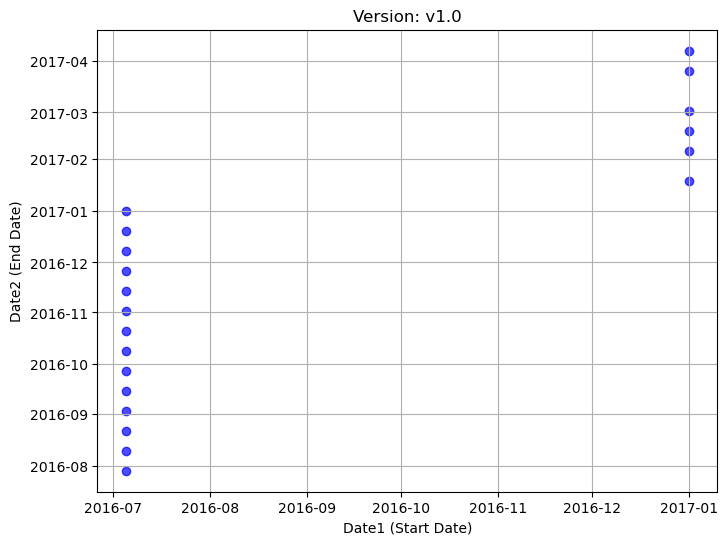

In [29]:
# Get all downoaded netcdfs
disp_df = product.get_disp_info(nc_dir)
#disp_df.head()

# Plot ministacks
def plot_date1_date2(ax, df):
    # Convert date1 and date2 to datetime format
    df = df.copy()
    df["date1"] = pd.to_datetime(df["date1"], format="%Y%m%d")
    df["date2"] = pd.to_datetime(df["date2"], format="%Y%m%d")

    # Plot
    ax.scatter(df.date1, df.date2, alpha=0.7, marker="o", color="b")

    # Labels and title
    ax.set_xlabel("Date1 (Start Date)")
    ax.set_ylabel("Date2 (End Date)")
    ax.set_title("Date1 vs. Date2")
    ax.grid(True)

versions = {}
for v in disp_df.version.unique():
    versions[v] = disp_df[disp_df.version == v].copy()
    print(f'{v}, size: {versions[v].shape[0]}')


for key, df in versions.items():
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_date1_date2(ax, df)
    ax.set_title(f'Version: {key}')

In [30]:
%%time
# Init production stack, stacking all mini-stacks
stack_prod = disp_stack.combine_disp_product(disp_df)
# Get the epsg code for the reference point
epsg = pyproj.CRS(stack_prod.spatial_ref.attrs['crs_wkt']).to_epsg()

CPU times: user 517 ms, sys: 52.6 ms, total: 570 ms
Wall time: 569 ms


In [31]:
stack_prod

<xarray.Dataset> Size: 1GB
Dimensions:                         (time: 21, y: 1484, x: 1041)
Coordinates:
  * y                               (y) float64 12kB 4.079e+06 ... 4.034e+06
  * x                               (x) float64 8kB 6.181e+05 ... 6.493e+05
  * time                            (time) datetime64[ns] 168B 2016-07-05T14:...
Data variables: (12/13)
    spatial_ref                     (time) int64 168B 0 0 0 0 0 0 ... 0 0 0 0 0
    reference_time                  (time) datetime64[ns] 168B dask.array<chunksize=(1,), meta=np.ndarray>
    displacement                    (time, y, x) float32 130MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    short_wavelength_displacement   (time, y, x) float32 130MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    recommended_mask                (time, y, x) float32 130MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    connected_component_labels      (time, y, x) float32 130MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ...                              ...
    estimated_phase_quality         (time, y, x) float32 130MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    persistent_scatterer_mask       (time, y, x) float32 130MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    shp_counts                      (time, y, x) float32 130MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    water_mask                      (time, y, x) float32 130MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    phase_similarity                (time, y, x) float32 130MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    timeseries_inversion_residuals  (time, y, x) float32 130MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
Attributes:
    Conventions:         CF-1.8
    contact:             opera-sds-ops@jpl.nasa.gov
    institution:         NASA JPL
    mission_name:        OPERA
    reference_document:  JPL D-108765
    title:               OPERA_L3_DISP-S1 Product

In [ ]:
import base64
import matplotlib.pyplot as plt
from io import BytesIO
from shapely.geometry import shape
from ipyleaflet import Map, ImageOverlay, DrawControl, LayersControl, basemaps
from ipywidgets import Output, VBox
import numpy as np
import pyproj
from pyproj import Transformer


####### CHOOSE A REFERENCE POINT #######
print("Please enable clicking point and choose a reference point by clicking on the map")

# Function: UTM to lat/lon
def utm_to_latlon(easting, northing, utm_epsg):
    transformer = Transformer.from_crs(f"epsg:{utm_epsg}", "epsg:4326", always_xy=True)
    lon, lat = transformer.transform(easting, northing)
    return lat, lon

# Get EPSG code from xarray CRS
utm_epsg = pyproj.CRS(stack_prod.spatial_ref.attrs['crs_wkt']).to_epsg()

# Prepare image from xarray
da = stack_prod.isel(time=-1).displacement

# Normalize the image
vmin, vmax = np.nanpercentile(da.values, [2, 98])
norm_img = np.clip((da.values - vmin) / (vmax - vmin), 0, 1)

# Plot the raster into a PNG buffer
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
ax.axis("off")
ax.imshow(norm_img, cmap='RdBu_r', origin='upper')
buf = BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0)
plt.close(fig)  
buf.seek(0)

# Convert UTM bounds to lat/lon
xmin, xmax = da.x.min().item(), da.x.max().item()
ymin, ymax = da.y.min().item(), da.y.max().item()

lat_min, lon_min = utm_to_latlon(xmin, ymin, utm_epsg)
lat_max, lon_max = utm_to_latlon(xmax, ymax, utm_epsg)
lat_center, lon_center = utm_to_latlon((xmin + xmax)/2, (ymin + ymax)/2, utm_epsg)

# Create map with Esri imagery
m = Map(center=(lat_center, lon_center), zoom=12, scroll_wheel_zoom=True, basemap=basemaps.Esri.WorldImagery)

# Add overlay with correct geographic bounds
overlay = ImageOverlay(
    url='data:image/png;base64,' + base64.b64encode(buf.read()).decode('utf-8'),
    bounds=((lat_min, lon_min), (lat_max, lon_max)),
    opacity=0.8,
)
m.add_layer(overlay)

# --- Point Click Logic Only ---
draw_out = Output()
click_toggle = ToggleButton(value=False, description='Enable Point Click', button_style='info')
clicked_ref_group = FeatureGroup(name='Selected Point')
m.add_layer(clicked_ref_group)

clicked_ref = {}

def handle_map_click(**kwargs):
    global clicked_ref
    if click_toggle.value and kwargs.get('type') == 'click':
        lat, lon = kwargs['coordinates']
        clicked_ref = {"lat": lat, "lon": lon}
        clicked_ref_group.clear_layers()
        clicked_ref_group.add_layer(CircleMarker(location=(lat, lon), radius=6, color="red", fill_color="red"))
        with draw_out:
            draw_out.clear_output()
            print("Clicked Point (lat/lon):")
            print(clicked_ref)

m.on_interaction(handle_map_click)
m.add_control(LayersControl())

# Display
display(VBox([click_toggle, m, draw_out]))


Please enable clicking point and choose a reference point by clicking on the map


In [33]:
# Define the reference point [lat, lon]
reference_yx = (clicked_ref['lat'], clicked_ref['lon'])
# Get the epsg code for the reference point
epsg = pyproj.CRS(stack_prod.spatial_ref.attrs['crs_wkt']).to_epsg()
# Get the reference point in UTM
ref_x_utm, ref_y_utm = latlon_to_utm(*reference_yx, epsg)
# Get the displacement at the reference point
ref_disp = stack_prod.sel(y=ref_y_utm, x=ref_x_utm, method='nearest').displacement
# Re-reference stack
stack_prod['displacement'] = stack_prod.displacement - ref_disp

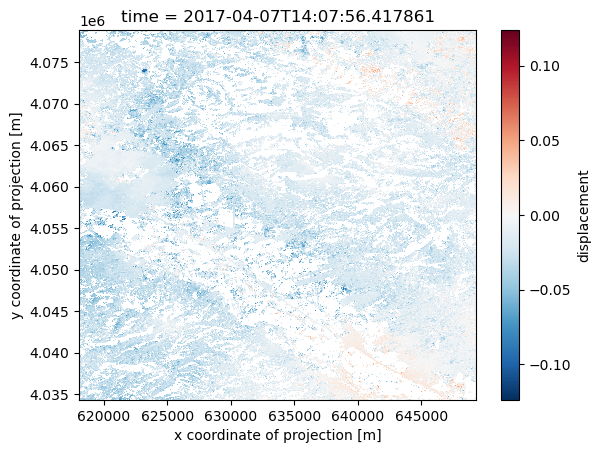

In [34]:
# Use recommended mask
stack_msk = stack_prod.where(stack_prod.recommended_mask==1)

# Plot cummulative displacement
stack_msk.chunk({'time':1}).isel(time=-1).displacement.plot.imshow()

## Optional: download static and auxiliary data

In [16]:
# Get the metadata from the first file.
out_dir = work_dir / 'static'
os.makedirs(out_dir, exist_ok=True)
# Copy the file to a writable location
shutil.copy(disp_df.path.iloc[0], Path(out_dir) / "temp_editable_disp.nc")

# Now modify it safely
with h5py.File(Path(out_dir) / "temp_editable_disp.nc", "a") as f:
    raw_bytes = f["metadata"]["pge_runconfig"][()]
    joined_bytes = b"".join(raw_bytes)

    del f["metadata"]["pge_runconfig"]
    f["metadata"].create_dataset("pge_runconfig", data=joined_bytes)
    
static_disp = static_layers.get_static_layers(Path(out_dir) / "temp_editable_disp.nc", out_dir)


Warning 6: merged.tif: NBITS is not supported for data type Int8


In [35]:
# Download DEM
dem = static_layers.download_dem(disp_df.path.iloc[0], out_dir)

Reading tile imagery: 100%|██████████| 1/1 [00:02<00:00,  2.43s/it]


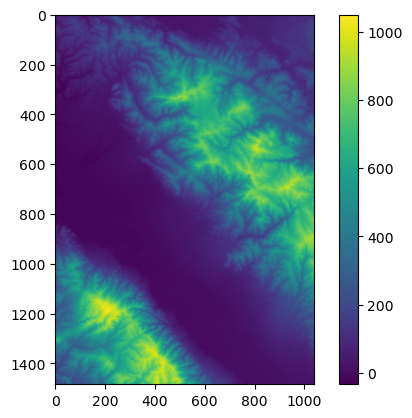

In [36]:
plt.imshow(io.open_image(dem)[0])
plt.colorbar()

# Stack Quality Metrics

In [37]:
# Some qualty layers are common for each ministack:
# "temporal_coherence", "phase_similarity", "persistent_scatterer_mask" ,"shp_counts"
stack_quality = stack_prod.chunk({'time':-1}) # Rechunk to take all data along dim time

ref_dates, indices = np.unique(stack_quality.reference_time, return_index=True)
ministack_ref = stack_prod.isel(time=indices)
ministack_ref = ministack_ref.chunk({'time':-1})

In [38]:
ministack_ref.persistent_scatterer_mask

<xarray.DataArray 'persistent_scatterer_mask' (time: 3, y: 1484, x: 1041)> Size: 19MB
dask.array<rechunk-merge, shape=(3, 1484, 1041), dtype=float32, chunksize=(3, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 12kB 4.079e+06 4.079e+06 ... 4.034e+06 4.034e+06
  * x        (x) float64 8kB 6.181e+05 6.181e+05 ... 6.492e+05 6.493e+05
  * time     (time) datetime64[ns] 24B 2016-07-05T14:07:55 ... 2017-01-19T14:...
Attributes:
    units:         unitless
    description:   Mask of persistent scatterers downsampled to the multilook...
    long_name:     Persistent Scatterer Mask
    grid_mapping:  spatial_ref

In [39]:
# Get percentage of PS stabilty in the stack
# Skip first date as it is all zero
pct_ps = quality_metrics.get_value_percentage(ministack_ref.persistent_scatterer_mask.isel(time=slice(1, None)), value=1)

# Percentage of recommended mask
pct_mask = quality_metrics.get_value_percentage(ministack_ref.recommended_mask.isel(time=slice(1, None)), value=1,
                                                reverse=False)

# Percentage of conncomponent zero
pct_conncomp = quality_metrics.get_value_percentage(stack_quality.connected_component_labels.isel(time=slice(1, None)),
                                                    value=0, reverse=True)

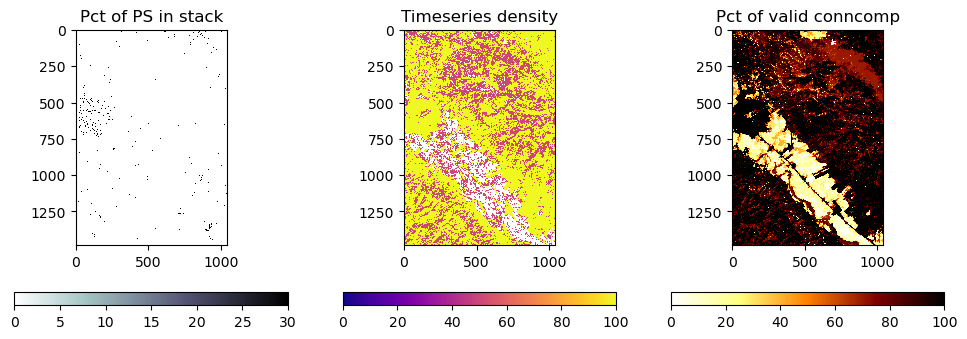

In [40]:
# Plot
fig, ax = plt.subplots(1,3, figsize=(12,4))
im1 = ax[0].imshow(np.ma.masked_equal(pct_ps,0), cmap='bone_r', clim=[0,30], interpolation='nearest')
im2 = ax[1].imshow(np.ma.masked_equal(pct_mask,0), cmap='plasma', clim=[0,100],interpolation='nearest')
im3 = ax[2].imshow(np.ma.masked_equal(pct_conncomp,0), cmap='afmhot_r', clim=[0,100], interpolation='nearest')
for a, im in zip(ax, [im1, im2, im3]):
    fig.colorbar(im, ax=a, location='bottom')
for a, txt in zip(ax, ['Pct of PS in stack',
                       'Timeseries density',
                       'Pct of valid conncomp']):
    a.set_title(txt)

In [41]:
# Other quality metrics
median_tcoh = quality_metrics.get_stack_stat(stack_quality.temporal_coherence.isel(time=slice(1, None)), mode='median') 
median_psim = quality_metrics.get_stack_stat(stack_quality.phase_similarity.isel(time=slice(1, None)), mode='median')  
inv_res_sum = quality_metrics.get_stack_stat(stack_quality.timeseries_inversion_residuals.isel(time=slice(1, None)), mode='sum')
num_2pi_jump = inv_res_sum / (2*np.pi)

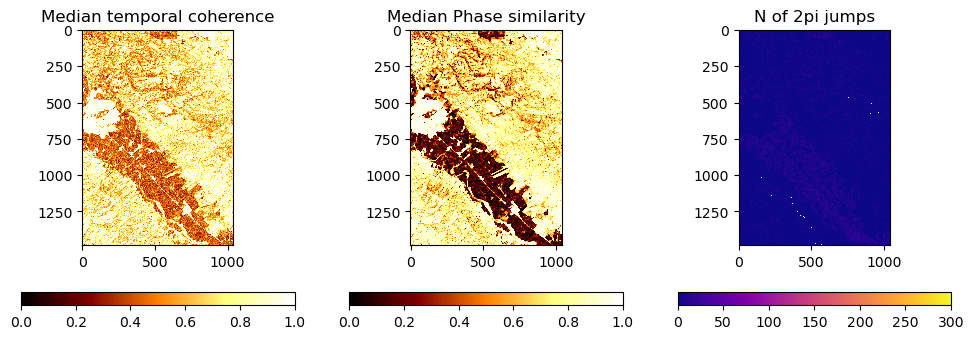

In [42]:
# Plot
fig, ax = plt.subplots(1,3, figsize=(12,4))
im1 = ax[0].imshow(np.ma.masked_equal(median_tcoh,0), cmap='afmhot', clim=[0,1], interpolation='nearest')
im2 = ax[1].imshow(np.ma.masked_equal(median_psim,0), cmap='afmhot', clim=[0,1],interpolation='nearest')
im3 = ax[2].imshow(np.ma.masked_equal(num_2pi_jump,0), cmap='plasma', clim=[0,300], interpolation='nearest')
for a, im in zip(ax, [im1, im2, im3]):
    fig.colorbar(im, ax=a, location='bottom')
for a, txt in zip(ax, ['Median temporal coherence',
                       'Median Phase similarity',
                       'N of 2pi jumps']):
    a.set_title(txt)

In [43]:
shp_median = quality_metrics.get_stack_stat(ministack_ref.shp_counts.isel(time=slice(1, None)), mode='median') 
shp_std = quality_metrics.get_stack_stat(ministack_ref.shp_counts.isel(time=slice(1, None)), mode='std')  

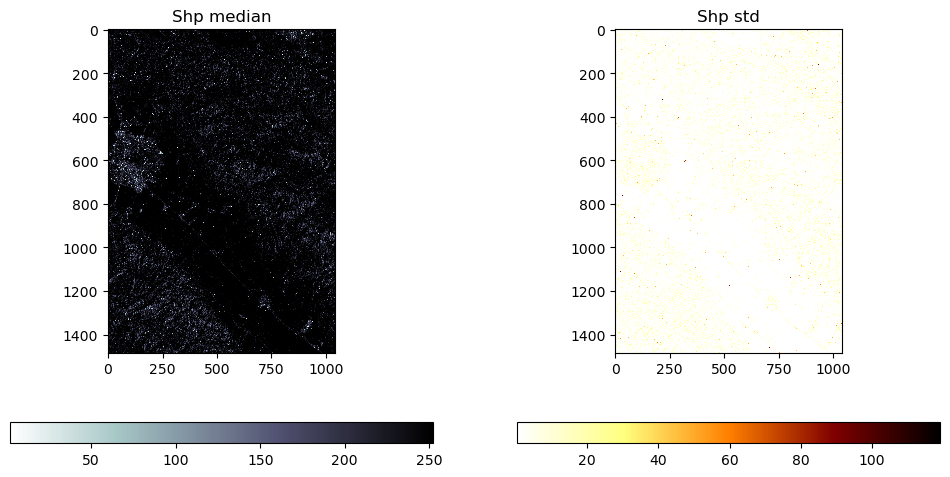

In [44]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
im1 = ax[0].imshow(np.ma.masked_equal(shp_median,0), cmap='bone_r', interpolation='nearest')
im2 = ax[1].imshow(np.ma.masked_equal(shp_std,0), cmap='afmhot_r', interpolation='nearest')
for a, im in zip(ax, [im1, im2, im3]):
    fig.colorbar(im, ax=a, location='bottom')
for a, txt in zip(ax, ['Shp median',
                       'Shp std']):
    a.set_title(txt)

# SUBSET DATA

If you have not decided to subset the data in the previous cells, you can do it now using a bounding box. \
Furthemore, the following cells allow you to compute the timeseries of a given point on the fly.

In [ ]:
import base64
import matplotlib.pyplot as plt
from io import BytesIO
from shapely.geometry import shape
from ipyleaflet import Map, ImageOverlay, DrawControl, LayersControl, basemaps
from ipywidgets import Output, VBox
import numpy as np
import pyproj
from pyproj import Transformer


#### ### CHOOSE A BBOX #######
print("Please choose a bounding box for subsetting point by clicking on the map")

# Function: UTM to lat/lon
def utm_to_latlon(easting, northing, utm_epsg):
    transformer = Transformer.from_crs(f"epsg:{utm_epsg}", "epsg:4326", always_xy=True)
    lon, lat = transformer.transform(easting, northing)
    return lat, lon

# Get EPSG code from xarray CRS
utm_epsg = pyproj.CRS(stack_msk.spatial_ref.attrs['crs_wkt']).to_epsg()

# Prepare image from xarray
da = stack_msk.isel(time=-1).displacement

# Normalize the image
vmin, vmax = np.nanpercentile(da.values, [2, 98])
norm_img = np.clip((da.values - vmin) / (vmax - vmin), 0, 1)

# Plot the raster into a PNG buffer
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
ax.axis("off")
ax.imshow(norm_img, cmap='RdBu_r', origin='upper')
buf = BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0)
plt.close(fig)  
buf.seek(0)

# Convert UTM bounds to lat/lon
xmin, xmax = da.x.min().item(), da.x.max().item()
ymin, ymax = da.y.min().item(), da.y.max().item()

lat_min, lon_min = utm_to_latlon(xmin, ymin, utm_epsg)
lat_max, lon_max = utm_to_latlon(xmax, ymax, utm_epsg)
lat_center, lon_center = utm_to_latlon((xmin + xmax)/2, (ymin + ymax)/2, utm_epsg)

# Create map with Esri imagery
m = Map(center=(lat_center, lon_center), zoom=12, scroll_wheel_zoom=True, basemap=basemaps.Esri.WorldImagery)

# Add overlay with correct geographic bounds
overlay = ImageOverlay(
    url='data:image/png;base64,' + base64.b64encode(buf.read()).decode('utf-8'),
    bounds=((lat_min, lon_min), (lat_max, lon_max)),
    opacity=0.8,
)
m.add_layer(overlay)

# Draw control for bounding box
draw_out = Output()
draw_control = DrawControl(circlemarker={}, polyline={}, circle={})
draw_control.rectangle = {
    "shapeOptions": {"fillColor": "#6be", "color": "red", "fillOpacity": 0.1, "weight": 2}
}

@draw_control.on_draw
def handle_draw(target, action, geo_json):
    global bbox_subset
    geom = shape(geo_json['geometry'])
    poly_wkt = geom.wkt
    bounds = geom.bounds
    bbox_subset = {
    "lon_min": bounds[0],
    "lon_max": bounds[2],
    "lat_min": bounds[1],
    "lat_max": bounds[3]
    }
    with draw_out:
        draw_out.clear_output()
        print("Bounding Box (lon/lat):")
        print({
            "lon_min": bounds[0],
            "lon_max": bounds[2],
            "lat_min": bounds[1],
            "lat_max": bounds[3]
        })

m.add_control(draw_control)
m.add_control(LayersControl())

display(VBox([m, draw_out]))


Please choose a bounding box for subsetting point by clicking on the map


In [46]:
bbox_subset
bounds =[bbox_subset['lon_min'],  bbox_subset['lat_min'],bbox_subset['lon_max'], bbox_subset['lat_max']]

min_x, min_y = latlon_to_utm(bounds[1], bounds[0], epsg)
max_x, max_y = latlon_to_utm(bounds[3], bounds[2], epsg) 

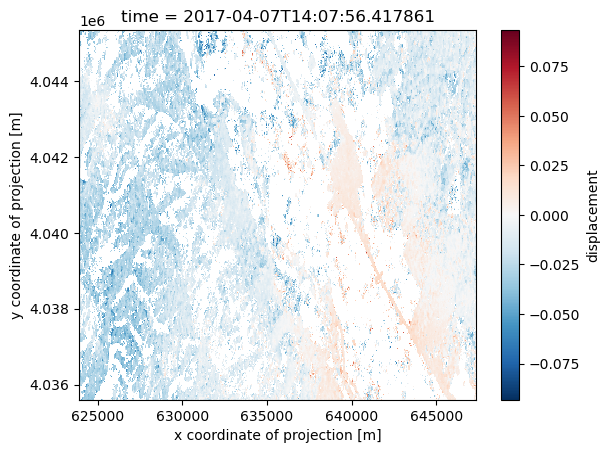

In [47]:
subset_stack = stack_msk.sel(x=slice(min_x, max_x), y=slice(max_y, min_y))
subset_stack.isel(time=-1).displacement.plot.imshow()

In [ ]:
import base64
import matplotlib.pyplot as plt
from io import BytesIO
from shapely.geometry import shape
from ipyleaflet import Map, ImageOverlay, DrawControl, LayersControl, basemaps
from ipywidgets import Output, VBox
import numpy as np
import pyproj
from pyproj import Transformer

######## CHOOSE A POINT FOR TIMESERIES ########
print("Please enable clicking point and choose a point for a timeseries by clicking on the map")

# Function: UTM to lat/lon
def utm_to_latlon(easting, northing, utm_epsg):
    transformer = Transformer.from_crs(f"epsg:{utm_epsg}", "epsg:4326", always_xy=True)
    lon, lat = transformer.transform(easting, northing)
    return lat, lon

# Get EPSG code from xarray CRS
utm_epsg = pyproj.CRS(subset_stack.spatial_ref.attrs['crs_wkt']).to_epsg()

# Prepare image from xarray
da = subset_stack.isel(time=-1).displacement

# Normalize the image
vmin, vmax = np.nanpercentile(da.values, [2, 98])
norm_img = np.clip((da.values - vmin) / (vmax - vmin), 0, 1)

# Plot the raster into a PNG buffer
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
ax.axis("off")
ax.imshow(norm_img, cmap='RdBu_r', origin='upper')
buf = BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0)
plt.close(fig)  
buf.seek(0)

# Convert UTM bounds to lat/lon
xmin, xmax = da.x.min().item(), da.x.max().item()
ymin, ymax = da.y.min().item(), da.y.max().item()

lat_min, lon_min = utm_to_latlon(xmin, ymin, utm_epsg)
lat_max, lon_max = utm_to_latlon(xmax, ymax, utm_epsg)
lat_center, lon_center = utm_to_latlon((xmin + xmax)/2, (ymin + ymax)/2, utm_epsg)

# Create map with Esri imagery
m = Map(center=(lat_center, lon_center), zoom=12, scroll_wheel_zoom=True, basemap=basemaps.Esri.WorldImagery)

# Add overlay with correct geographic bounds
overlay = ImageOverlay(
    url='data:image/png;base64,' + base64.b64encode(buf.read()).decode('utf-8'),
    bounds=((lat_min, lon_min), (lat_max, lon_max)),
    opacity=0.8,
)
m.add_layer(overlay)

# --- Point Click Logic Only ---
draw_out = Output()
click_toggle = ToggleButton(value=False, description='Enable Point Click', button_style='info')
clicked_point_group = FeatureGroup(name='Selected Point')
m.add_layer(clicked_point_group)

clicked_point = {}

def handle_map_click(**kwargs):
    global clicked_point
    if click_toggle.value and kwargs.get('type') == 'click':
        lat, lon = kwargs['coordinates']
        clicked_point = {"lat": lat, "lon": lon}
        clicked_point_group.clear_layers()
        clicked_point_group.add_layer(CircleMarker(location=(lat, lon), radius=6, color="red", fill_color="red"))
        with draw_out:
            draw_out.clear_output()
            print("Clicked Point (lat/lon):")
            print(clicked_point)

m.on_interaction(handle_map_click)
m.add_control(LayersControl())

# Display
display(VBox([click_toggle, m, draw_out]))


Please enable clicking point and choose a point for a timeseries by clicking on the map


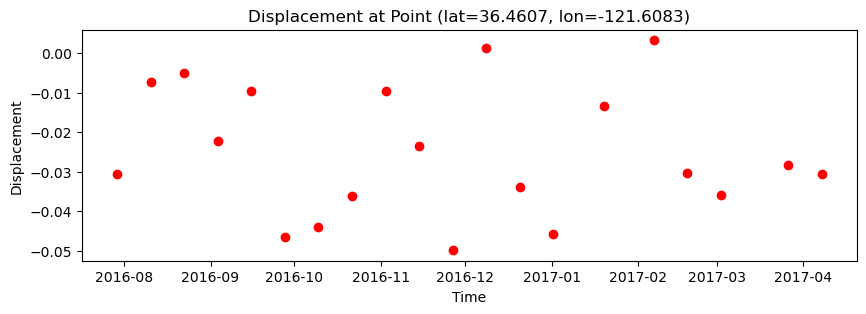

In [50]:
# pick a point on levee
xy = latlon_to_utm(clicked_point['lat'],clicked_point['lon'], epsg)

import matplotlib.pyplot as plt

# Extract the time series at the nearest point
ts = subset_stack.sel(x=xy[0], y=xy[1], method='nearest').displacement

# Create plot
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ts.time, ts.values, marker='o', linestyle='', color='red', label='Clicked Point')

# Set title and labels
lat = clicked_point['lat']
lon = clicked_point['lon']
ax.set_title(f"Displacement at Point (lat={lat:.4f}, lon={lon:.4f})")
ax.set_xlabel("Time")
ax.set_ylabel("Displacement")

plt.show()


# Interactive subsetting and plotting of the OPERA DISP-S1

In [52]:
def rereference_plot(stack_xr, ref_yx, time=-1, mask=True):
    # Get the epsg code for the reference point
    epsg = pyproj.CRS(stack_xr.spatial_ref.attrs['crs_wkt']).to_epsg()

    # Get the reference point in UTM
    ref_x_utm, ref_y_utm = latlon_to_utm(*ref_yx, epsg)

    # Get the displacement at the reference point
    ref_disp = stack_xr.sel(y=ref_y_utm, x=ref_x_utm,
                            method='nearest').displacement

    # Re-reference stack
    stack_xr['displacement'] = stack_xr.displacement - ref_disp

    if mask:
        # Use recommended mask
        stack_msk = stack_xr.where(stack_xr.recommended_mask==1)

        # Plot cummulative displacement
        stack_msk.chunk({'time':1}).isel(time=time).displacement.plot.imshow()
    else:
        stack_xr.chunk({'time':1}).isel(time=time).displacement.plot.imshow()

def rereference_tsplot(stack_xr, ref_yx, ts_yx, mask=True):
    # Get the epsg code for the reference point
    epsg = pyproj.CRS(stack_xr.spatial_ref.attrs['crs_wkt']).to_epsg()

    # Get the reference point in UTM
    ref_x_utm, ref_y_utm = latlon_to_utm(*ref_yx, epsg)

    # Get the displacement at the reference point
    ref_disp = stack_xr.sel(y=ref_y_utm, x=ref_x_utm,
                            method='nearest').displacement

    # Re-reference stack
    stack_xr['displacement'] = stack_xr.displacement - ref_disp
    kwargs = {'marker':'o', 'linewidth':0}
    if mask:
        # Use recommended mask
        stack_msk = stack_xr.where(stack_xr.recommended_mask==1)

        # Plot cummulative displacement
        stack_msk.sel(y=ts_yx[0], x=ts_yx[1], method='nearest').displacement.plot(**kwargs)
    else:
        stack_xr.sel(y=ts_yx[0], x=ts_yx[1], method='nearest').displacement.plot(**kwargs)

def rereference_plot_wgs(stack_xr, ref_yx, time=-1, mask=True):
    # Get the epsg code for the reference point
    epsg = pyproj.CRS(stack_xr.spatial_ref.attrs['crs_wkt']).to_epsg()

    # Get the reference point in UTM
    ref_x_utm, ref_y_utm = latlon_to_utm(*ref_yx, epsg)

    # Get the displacement at the reference point
    ref_disp = stack_xr.sel(y=ref_y_utm, x=ref_x_utm,
                            method='nearest').displacement

    # Re-reference stack
    stack_xr['displacement'] = stack_xr.displacement - ref_disp

    if mask:
        # Use recommended mask
        stack_msk = stack_xr.where(stack_xr.recommended_mask==1)

        # Plot cummulative displacement
        st_xr = stack_msk.chunk({'time':1}).isel(time=time).displacement
    else:
        st_xr = stack_xr.chunk({'time':1}).isel(time=time).displacement

    st_xr.rio.write_crs(epsg, inplace=True)
    # print reproject
    st_xr_wgs = st_xr.rio.reproject(4326)

    st_xr_wgs = st_xr_wgs.fillna(-9999)
    st_xr_wgs.rio.write_nodata(-9999, inplace=True)

    # Save as Cloud-Optimized GeoTIFF (COG)
    st_xr_wgs.rio.to_raster("cogeo.tif", driver="COG", compress="deflate", tiled=True, windowed=True)

In [ ]:
import base64
import matplotlib.pyplot as plt
from io import BytesIO
from shapely.geometry import shape
from ipyleaflet import Map, ImageOverlay, DrawControl, LayersControl, basemaps
from ipywidgets import Output, VBox
import numpy as np
import pyproj
from pyproj import Transformer

######## CHOOSE A REFERENCE POINT ########
print("Please enable clicking point and choose a reference point by clicking on the map")

# Function: UTM to lat/lon
def utm_to_latlon(easting, northing, utm_epsg):
    transformer = Transformer.from_crs(f"epsg:{utm_epsg}", "epsg:4326", always_xy=True)
    lon, lat = transformer.transform(easting, northing)
    return lat, lon

# Get EPSG code from xarray CRS
utm_epsg = pyproj.CRS(stack_prod.spatial_ref.attrs['crs_wkt']).to_epsg()

# Prepare image from xarray
da = stack_prod.isel(time=-1).displacement

# Normalize the image
vmin, vmax = np.nanpercentile(da.values, [2, 98])
norm_img = np.clip((da.values - vmin) / (vmax - vmin), 0, 1)

# Plot the raster into a PNG buffer
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
ax.axis("off")
ax.imshow(norm_img, cmap='RdBu_r', origin='upper')
buf = BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0)
plt.close(fig)  
buf.seek(0)

# Convert UTM bounds to lat/lon
xmin, xmax = da.x.min().item(), da.x.max().item()
ymin, ymax = da.y.min().item(), da.y.max().item()

lat_min, lon_min = utm_to_latlon(xmin, ymin, utm_epsg)
lat_max, lon_max = utm_to_latlon(xmax, ymax, utm_epsg)
lat_center, lon_center = utm_to_latlon((xmin + xmax)/2, (ymin + ymax)/2, utm_epsg)

# Create map with Esri imagery
m = Map(center=(lat_center, lon_center), zoom=12, scroll_wheel_zoom=True, basemap=basemaps.Esri.WorldImagery)

# Add overlay with correct geographic bounds
overlay = ImageOverlay(
    url='data:image/png;base64,' + base64.b64encode(buf.read()).decode('utf-8'),
    bounds=((lat_min, lon_min), (lat_max, lon_max)),
    opacity=0.8,
)
m.add_layer(overlay)

# --- Point Click Logic Only ---
draw_out = Output()
click_toggle = ToggleButton(value=False, description='Enable Point Click', button_style='info')
clicked_point_group_int = FeatureGroup(name='Selected Point')
m.add_layer(clicked_point_group_int)

clicked_point_int = {}

def handle_map_click(**kwargs):
    global clicked_point_int
    if click_toggle.value and kwargs.get('type') == 'click':
        lat, lon = kwargs['coordinates']
        clicked_point_int = {"lat": lat, "lon": lon}
        clicked_point_group_int.clear_layers()
        clicked_point_group_int.add_layer(CircleMarker(location=(lat, lon), radius=6, color="red", fill_color="red"))
        with draw_out:
            draw_out.clear_output()
            print("Clicked Point (lat/lon):")
            print(clicked_point_int)

m.on_interaction(handle_map_click)
m.add_control(LayersControl())

# Display
display(VBox([click_toggle, m, draw_out]))


Please enable clicking point and choose a reference point by clicking on the map


In [54]:
# Define the reference point [lat, lon]
reference_yx = (clicked_point_int['lat'], clicked_point_int['lon'])

CHOOSE A SUBSETTING WINDOW / BBOX AND OR A POINT FOR TIMESERIES PLOTTING


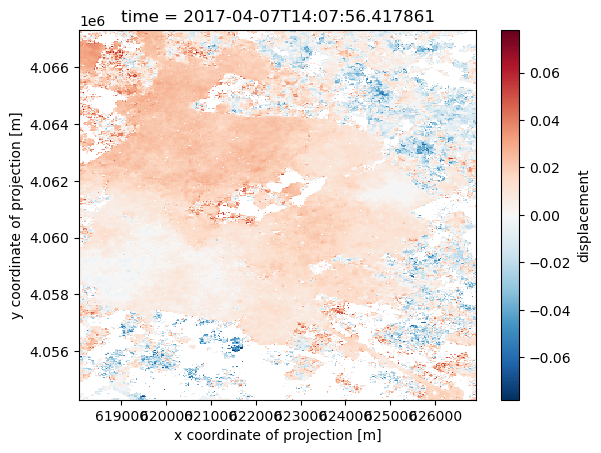

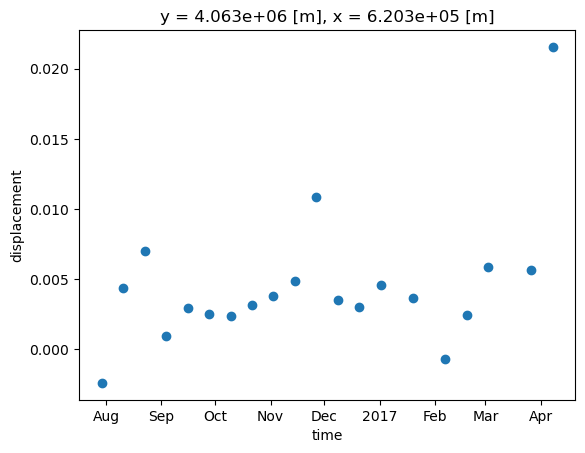

In [55]:
from curses.panel import bottom_panel
from ipyleaflet import (Map, GeoJSON, DrawControl, 
                        LayersControl, TileLayer)
from ipywidgets import Output, ToggleButton, VBox, interactive, widgets
from shapely.geometry import shape, Polygon, Point
import geopandas as gpd
import shapely.ops
import rioxarray
from shapely import wkt
from pyproj import Transformer, CRS


######## CHOOSE A SUBSETTING WINDOW / BBOX AND OR A POINT FOR TIMESERIES PLOTTING ########
print('CHOOSE A SUBSETTING WINDOW / BBOX AND OR A POINT FOR TIMESERIES PLOTTING')

# Clean GeoDataFrame
gdf = gpd.GeoDataFrame(products_df.copy(), crs=4326)
gdf = gdf.map(lambda x: x.isoformat() if isinstance(x, pd.Timestamp) else x)

# Get map center
center = gdf.geometry.union_all().centroid

# Create map with Esri background and arrow cursor
m = Map(
    center=(center.y, center.x),
    zoom=6,
    scroll_wheel_zoom=True,
    basemap=basemaps.Esri.WorldImagery
)
m.layout.cursor = 'default'

# Add DISP GeoJSON layer
style = {'color': 'blue', 'weight': 1, 'fillColor': 'transparent', 'fillOpacity': 0.0}
hover_style = {'color': 'blue', 'fillOpacity': 0.1}
geojson_layer = GeoJSON(data=gdf.__geo_interface__, name="OPERA_DISP", style=style, hover_style=hover_style)
m.add_layer(geojson_layer)

# ▶️ Add stack_prod[-1] as raster overlay
da = stack_prod.isel(time=-1).displacement
vmin, vmax = np.nanpercentile(da.values, [2, 98])
norm_img = np.clip((da.values - vmin) / (vmax - vmin), 0, 1)

# Render to PNG in memory
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
ax.axis("off")
ax.imshow(norm_img, cmap='RdBu_r', origin='upper')
buf = BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0)
plt.close(fig)
buf.seek(0)

# Compute map bounds in lat/lon
utm_epsg = pyproj.CRS(stack_prod.spatial_ref.attrs['crs_wkt']).to_epsg()
xmin, xmax = da.x.min().item(), da.x.max().item()
ymin, ymax = da.y.min().item(), da.y.max().item()
transformer = Transformer.from_crs(utm_epsg, 4326, always_xy=True)
lon_min, lat_min = transformer.transform(xmin, ymin)
lon_max, lat_max = transformer.transform(xmax, ymax)

img_overlay = ImageOverlay(
    url='data:image/png;base64,' + base64.b64encode(buf.read()).decode('utf-8'),
    bounds=((lat_min, lon_min), (lat_max, lon_max)),
    opacity=0.8,
    name="Displacement"
)
m.add_layer(img_overlay)
# Add Drawing box
draw_out = Output()
draw_control = DrawControl(
    marker={},             # disable marker
    polyline={},           # disable polyline
    polygon={},            # disable polygon
    circlemarker={}        # disable circle marker
)

# Enable rectangle drawing
# Enable only rectangle and circle
draw_control.rectangle = {
    "shapeOptions": {"fillColor": "#6be", "color": "red", "fillOpacity": 0.1, "weight": 2}
}
draw_control.circlemarker = {
    "shapeOptions": {"fillColor": "#f03", "color": "red", "fillOpacity": 0.1, "weight": 2}
}

# Drawn geometry output
@draw_control.on_draw
def handle_draw(target, action, geo_json):
    geom = shape(geo_json['geometry'])
    poly_wkt = geom.wkt
    with draw_out:
        #draw_out.clear_output()
        print("Drawn Geometry WKT:\n", poly_wkt)

    print("Loading data, please wait few seconds")
    # Load WKT and convert to raster CRS
    aoi = wkt.loads(poly_wkt)
    epsg = pyproj.CRS(stack_prod.spatial_ref.attrs['crs_wkt']).to_epsg()

    # Transform AOI to raster projection
    if isinstance(geom, Point):
        transformer = Transformer.from_crs(4326, CRS.from_epsg(epsg), always_xy=True)
        aoi_utm = shapely.ops.transform(transformer.transform, aoi)
        left, bottom, right, top = aoi_utm.bounds
        rereference_tsplot(stack_prod, reference_yx, (bottom, left))
    elif isinstance(geom, Polygon):
        transformer = Transformer.from_crs(4326, CRS.from_epsg(epsg), always_xy=True)
        aoi_utm = shapely.ops.transform(transformer.transform, aoi)
        left, bottom, right, top = aoi_utm.bounds

        # Subset raster
        stack_subset = stack_prod.sel(y=slice(top, bottom), x=slice(left, right))

        rereference_plot(stack_subset, reference_yx)



# Add to map
m.add_control(draw_control)

# Toggle button for enabling/disabling point clicks
click_toggle = ToggleButton(value=False, description='Enable Point Click', button_style='success')

m.add_control(LayersControl(position='topright'))

# Display everything
display(VBox([click_toggle, m, draw_out]))


## Get Velocity

In [56]:
p = stack_prod.displacement.polyfit(dim='time', deg=1, skipna=True, full=True, cov=True)

In [57]:
%%time
velocity = p.polyfit_coefficients.compute()

CPU times: user 39.6 s, sys: 4.82 s, total: 44.4 s
Wall time: 40.5 s


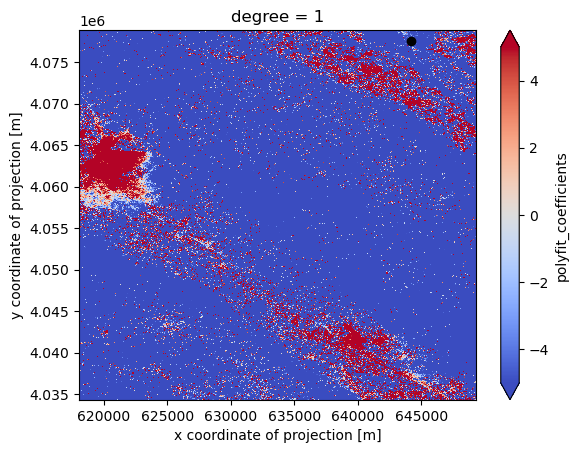

In [58]:
ns2yr = 1e9 * 60 * 60 * 24 * 365.25 # nanoseconds to years
fig, ax = plt.subplots(1)
(velocity.isel(degree=0) * ns2yr*1e3).plot.imshow(ax=ax, vmin=-5, vmax=5, cmap='coolwarm') #mm/yr
ax.plot(ref_x_utm, ref_y_utm, 'ko')